# Bloque 0 — Preparación de datos, features y etiquetado

**TFM: Machine Learning aplicado a la gestión de Inversiones**  
**Línea 1:** Identificación de Regímenes y Destilación de Modelos en Datos Diarios del S&P 500

---

## Objetivo de este bloque

Este notebook cubre los pasos previos al modelado:

1. **Variables objetivo** — log-retornos diarios (referencia base)
2. **Indicadores técnicos** sobre el precio del S&P 500
3. **Variables macroeconómicas** desde FRED (VIX, UNRATE, spreads, etc.)
4. **Sectores** — retornos de ETFs sectoriales como proxy de rotación
5. **Features adicionales** — retornos multi-periodo, vol-regime, drawdown
6. **Etiqueta Triple Barrier** con barreras dinámicas basadas en volatilidad
7. **Análisis diagnóstico** del etiquetado (distribución, calidad de señal)
8. **Limpieza de variables** por correlación y VIF

---

> **Nota sobre reproducibilidad:** Todas las funciones que involucran aleatoriedad
> fijan `random_state`. Los datos descargados se guardan en Parquet para evitar
> variaciones entre descargas. La semilla global se fija al inicio del notebook.

---
# 0. Configuración global

Fijamos la semilla global y definimos las constantes del proyecto.
Centralizar estos parámetros aquí facilita cambiarlos en un solo lugar
y garantiza que todos los resultados sean reproducibles entre ejecuciones.

In [63]:
import random
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------
# SEMILLA GLOBAL — fijar antes de cualquier operación
# ----------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------------------------------------
# PARÁMETROS DEL PROYECTO
# ----------------------------------------------------------
# Periodo de datos
START_DATE   = '2004-01-01'   # Inicio descarga (margen para warm-up de indicadores)
TRAIN_END    = '2019-12-31'   # Fin del periodo train-validación
OOS_START    = '2020-01-01'   # Inicio del periodo OOS — NO TOCAR hasta evaluación final
OOS_END      = '2024-12-31'   # Fin del periodo OOS

# Activo principal
TICKER_SP500 = '^GSPC'

# ETFs sectoriales
SECTOR_ETFS  = ['XLK', 'XLV', 'XLF', 'XLE', 'XLI', 'XLY']

# Parámetros Triple Barrier (según guía del TFM)
TB_K            = 0.7   # Multiplicador de volatilidad para las barreras
TB_VOL_SPAN     = 20    # Ventana EWM para calcular la volatilidad dinámica
TB_MAX_HOLDING  = 7     # Horizonte máximo en días de trading

# Umbral de alerta: si la barrera temporal se activa más del 40%, revisar k
TB_MAX_TEMPORAL_RATIO = 0.40

# Parámetros limpieza de variables
CORR_THRESHOLD = 0.95   # Eliminar si |correlación| > este valor
VIF_THRESHOLD  = 10.0   # Eliminar si VIF > este valor

print('✅ Configuración global cargada')
print(f'   Periodo train-val : {START_DATE}  →  {TRAIN_END}')
print(f'   Periodo OOS       : {OOS_START}  →  {OOS_END}')
print(f'   Semilla global    : {SEED}')
print(f'   Ticker principal  : {TICKER_SP500}')
print(f'   Triple Barrier    : k={TB_K}, span={TB_VOL_SPAN}, max_holding={TB_MAX_HOLDING}')

✅ Configuración global cargada
   Periodo train-val : 2004-01-01  →  2019-12-31
   Periodo OOS       : 2020-01-01  →  2024-12-31
   Semilla global    : 42
   Ticker principal  : ^GSPC
   Triple Barrier    : k=0.7, span=20, max_holding=7


---
# 1. Variable objetivo base — Log-retornos diarios

Calculamos los log-retornos diarios del precio de cierre.
Usamos logaritmos porque son más estables estadísticamente que los retornos
simples, son aditivos en el tiempo y su distribución se aproxima mejor
a la normalidad, lo que facilita el trabajo con modelos de ML.

> Esta variable actúa como **target de referencia** para análisis exploratorio.
> El target definitivo para los modelos será la etiqueta Triple Barrier (Sección 6).

In [64]:
def create_target_returns(df: pd.DataFrame, price_col: str = 'Close') -> pd.DataFrame:
    """
    Calcula los log-retornos diarios del precio de cierre.

    Los log-retornos (ln(P_t / P_{t-1})) son la representación estándar
    en finanzas cuantitativas por su aditividad temporal y mayor estabilidad
    estadística frente a retornos simples.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con al menos la columna `price_col`.
    price_col : str, optional
        Nombre de la columna de precios de cierre (default: 'Close').

    Returns
    -------
    pd.DataFrame
        DataFrame original con la columna 'target_return_1d' añadida.
    """
    df = df.copy()

    # Log-retorno diario: ln(Close_t / Close_{t-1})
    df['target_return_1d'] = np.log(df[price_col] / df[price_col].shift(1))

    return df


print('✅ Función create_target_returns definida')

✅ Función create_target_returns definida


---
# 2. Indicadores técnicos

Construimos un conjunto de indicadores técnicos clásicos que capturan
distintas dimensiones del comportamiento del precio:

| Grupo | Indicadores | Hipótesis |
|---|---|---|
| Tendencia | SMA 10/50, EMA 10 | El precio tiende a revertir o seguir la media |
| Momentum | RSI(14), momentum 5/20d | Los movimientos recientes predicen los futuros |
| Volatilidad | Volatilidad rolling 20d, ATR(14) | La volatilidad es persistente (clustering) |
| Reversión a la media | Z-score 20d | El precio se aleja y vuelve a su media |
| Fuerza de tendencia | Ratio SMA10/SMA50 | La relación entre medias corta y larga mide el régimen |

> **Importante:** La volatilidad EWM de 20 días se calcula en esta función
> y también se usará como input directo de la Triple Barrier (Sección 6).

In [65]:
def add_technicals(df: pd.DataFrame) -> pd.DataFrame:
    """
    Añade indicadores técnicos al DataFrame de precios del S&P 500.

    Calcula indicadores de tendencia, momentum, volatilidad y reversión
    a la media. Todos los indicadores se calculan únicamente con datos
    pasados (no hay look-ahead).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columnas OHLCV ('Open', 'High', 'Low', 'Close', 'Volume').

    Returns
    -------
    pd.DataFrame
        DataFrame original con las siguientes columnas añadidas:
        - sma_10, sma_50      : medias móviles simples
        - ema_10              : media móvil exponencial
        - momentum_5/20       : retorno porcentual a 5 y 20 días
        - rsi                 : Relative Strength Index (14 periodos)
        - vol_ewm_20          : volatilidad EWM span=20 sobre log-retornos
        - volatility_20       : volatilidad rolling 20d (para ATR y z-score)
        - atr_14              : Average True Range (14 periodos)
        - zscore_20           : z-score del precio respecto a su media 20d
        - trend_strength      : ratio SMA10/SMA50
    """
    df = df.copy()

    # --------------------------------------------------------
    # LOG-RETORNOS (base para vol_ewm y otras features)
    # --------------------------------------------------------
    ret = np.log(df['Close'] / df['Close'].shift(1))

    # --------------------------------------------------------
    # TENDENCIA — Medias móviles
    # --------------------------------------------------------
    df['sma_10'] = df['Close'].rolling(10).mean()
    df['sma_50'] = df['Close'].rolling(50).mean()
    df['ema_10'] = df['Close'].ewm(span=10, adjust=False).mean()

    # --------------------------------------------------------
    # MOMENTUM
    # --------------------------------------------------------
    df['momentum_5']  = df['Close'].pct_change(5)
    df['momentum_20'] = df['Close'].pct_change(20)

    # RSI de 14 periodos (Wilder, 1978)
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))

    # --------------------------------------------------------
    # VOLATILIDAD
    # --------------------------------------------------------
    # EWM span=20 sobre log-retornos — parámetro fijado por la guía del TFM
    # Esta es la volatilidad que se usará en la Triple Barrier
    df['vol_ewm_20'] = ret.ewm(span=TB_VOL_SPAN, adjust=False).std()

    # Rolling std 20d — para z-score y ATR
    df['volatility_20'] = df['Close'].rolling(20).std()

    # ATR (Average True Range, 14 periodos)
    high_low    = df['High'] - df['Low']
    high_close  = np.abs(df['High'] - df['Close'].shift(1))
    low_close   = np.abs(df['Low']  - df['Close'].shift(1))
    tr          = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['atr_14'] = tr.rolling(14).mean()

    # --------------------------------------------------------
    # REVERSIÓN A LA MEDIA
    # --------------------------------------------------------
    rolling_mean = df['Close'].rolling(20).mean()
    rolling_std  = df['Close'].rolling(20).std()
    df['zscore_20'] = (df['Close'] - rolling_mean) / rolling_std

    # --------------------------------------------------------
    # FUERZA DE TENDENCIA
    # --------------------------------------------------------
    # Ratio SMA corta / SMA larga: >1 indica tendencia alcista, <1 bajista
    df['trend_strength'] = df['sma_10'] / df['sma_50']

    return df


print('✅ Función add_technicals definida')

✅ Función add_technicals definida


---
# 3. Variables macroeconómicas (FRED)

Incorporamos indicadores macroeconómicos que aportan contexto sobre el
estado del ciclo económico y las condiciones de mercado. Estas variables
son especialmente relevantes porque los modelos de regímenes (Iteración 2)
también se apoyarán en el **VIX** como proxy de incertidumbre de mercado.

Las series de baja frecuencia (mensuales, trimestrales) se remuestrean a
frecuencia diaria mediante **forward fill**, que es el único método causal
posible (usamos el último dato publicado hasta que haya uno nuevo).

| Variable FRED | Nombre interno | Frecuencia | Descripción |
|---|---|---|---|
| VIXCLS | vix | Diaria | Índice de volatilidad implícita (fear index) |
| UNRATE | empleo | Mensual | Tasa de desempleo USA |
| T10Y3M | yield_curve | Diaria | Spread curva de tipos (indicador recesión) |
| BAMLC0A0CM | corp_oas | Diaria | Spread crédito investment grade |
| BAMLH0A0HYM2 | hy_oas | Diaria | Spread crédito high yield |
| JHDUSRGDPBR | recession | Mensual | Probabilidad de recesión (Hamilton) |
| GDPC1 | real_gdp | Trimestral | PIB real USA |
| DCOILWTICO | oil | Diaria | Precio del petróleo WTI |
| USSLIND | leading | Mensual | Índice líder USA |
| ICSA | weekjobclaims | Semanal | Solicitudes semanales de paro |
| DGS1 | 1y_yield | Diaria | Rendimiento bono USA 1 año |

In [66]:
import pandas_datareader.data as web


def get_fred_data(end_year: int) -> pd.DataFrame:
    """
    Descarga y preprocesa variables macroeconómicas desde FRED.

    Descarga cada serie individualmente para que un fallo o ausencia de datos
    en una variable no afecte al resto. Las series de baja frecuencia
    (mensual, trimestral) se remuestrean a diaria con forward fill causal.
    Se aplica bfill solo al inicio de la serie (antes del primer dato real)
    para evitar NaN en el periodo 2004-2008 donde algunas series aún no
    existían, rellenando con el primer valor disponible hacia atrás.

    Parameters
    ----------
    end_year : int
        Año final de descarga (inclusive). Ejemplo: 2024.

    Returns
    -------
    pd.DataFrame
        Series macro a frecuencia diaria con columnas renombradas.
        Índice de tipo DatetimeIndex.
    """
    # Códigos FRED y nombres descriptivos
    indicators = [
        'JHDUSRGDPBR', 'T10Y3M',     'BAMLC0A0CM',  'BAMLH0A0HYM2',
        'BAMLHE00EHYIOAS', 'UMCSENT', 'UNRATE',      'GDPC1',
        'DCOILWTICO',  'CORESTICKM159SFRBATL', 'USSLIND',
        'VIXCLS',      'OVXCLS',     'ICSA',
        'MARTSMPCSM44000USS', 'RSXFS', 'TREAST',     'DGS1'
    ]
    var_names = [
        'recession',   'yield_curve', 'corp_oas',    'hy_oas',
        'eu_hy_oas',   'sentiment',   'empleo',      'real_gdp',
        'oil',         'inflacion',   'leading',
        'vix',         'vixoil',      'weekjobclaims',
        'retail_sales_percent', 'retail_sales', 'us_asset_balance', '1y_yield'
    ]

    # Índice diario completo desde 2000 (margen para warm-up)
    daily_index = pd.date_range(start='2000-01-01',
                                end=f'{end_year}-12-31', freq='D')
    result = pd.DataFrame(index=daily_index)

    for code, name in zip(indicators, var_names):
        try:
            serie = web.DataReader(code, 'fred', '2000-01-01', f'{end_year}-12-31')
            serie = (
                serie
                .resample('D').last()          # Normalizar a diaria
                .reindex(daily_index)           # Alinear al índice completo
                .ffill()                        # Forward fill causal
                .bfill()                        # Bfill solo para NaN iniciales
            )
            result[name] = serie[code]
        except Exception as e:
            print(f'  ⚠️  No se pudo descargar {code} ({name}): {e}')
            result[name] = np.nan  # Columna vacía si falla la descarga

    return result


print('✅ Función get_fred_data definida')

✅ Función get_fred_data definida


---
# 4. Retornos sectoriales (ETFs)

Incorporamos la rotación sectorial como signal de momentum relativo.
Usamos los 6 principales ETFs del SPDR para capturar el comportamiento
diferencial entre sectores del S&P 500.

La lógica es que el flujo de capital entre sectores anticipa movimientos
del índice: si el dinero fluye a defensivos (XLV, consumo básico) es señal
de cautela; si fluye a cíclicos (XLK, XLY) es señal de apetito por riesgo.

In [67]:
def get_sector_returns(start: str, end: str, tickers: list) -> pd.DataFrame:
    """
    Descarga precios de ETFs sectoriales y calcula sus log-retornos diarios.

    Parameters
    ----------
    start : str
        Fecha de inicio en formato 'YYYY-MM-DD'.
    end : str
        Fecha de fin en formato 'YYYY-MM-DD'.
    tickers : list of str
        Lista de tickers de ETFs sectoriales (ej. ['XLK', 'XLV', ...]).

    Returns
    -------
    pd.DataFrame
        Log-retornos diarios con columnas prefijadas 'sector_TICKER'.
    """
    import yfinance as yf

    prices = yf.download(tickers, start=start, auto_adjust=True)['Close']

    # Log-retornos diarios
    returns = np.log(prices / prices.shift(1))
    returns.columns = [f'sector_{c}' for c in returns.columns]

    return returns


print('✅ Función get_sector_returns definida')

✅ Función get_sector_returns definida


---
# 5. Features adicionales

Añadimos tres grupos de features complementarias:

- **Retornos multi-periodo** (1d, 5d, 20d): capturan el momentum a distintos horizontes.
- **Vol-regime**: ratio entre la volatilidad actual y su media histórica 50d,
  indicando si el mercado está en un régimen de alta o baja volatilidad relativa.
- **Drawdown desde máximo**: mide la distancia al máximo histórico móvil,
  capturando el estado de stress del mercado.

In [68]:
def add_extra_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Añade retornos multi-periodo, régimen de volatilidad y drawdown.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columna 'Close' y 'volatility_20' (de add_technicals).

    Returns
    -------
    pd.DataFrame
        DataFrame con las siguientes columnas añadidas:
        - return_1d, return_5d, return_20d : log-retornos acumulados
        - vol_regime  : vol_20d actual / vol_20d media 50d (ratio de régimen)
        - drawdown    : caída porcentual desde el máximo histórico rolling
    """
    df = df.copy()

    # --------------------------------------------------------
    # RETORNOS ACUMULADOS (log-retornos son aditivos)
    # --------------------------------------------------------
    df['return_1d']  = np.log(df['Close'] / df['Close'].shift(1))
    df['return_5d']  = df['return_1d'].rolling(5).sum()    # ≈ 1 semana
    df['return_20d'] = df['return_1d'].rolling(20).sum()   # ≈ 1 mes

    # --------------------------------------------------------
    # RÉGIMEN DE VOLATILIDAD
    # --------------------------------------------------------
    # >1 → volatilidad actual por encima de su media histórica (régimen de estrés)
    # <1 → volatilidad por debajo de su media histórica (régimen tranquilo)
    df['vol_regime'] = df['volatility_20'] / df['volatility_20'].rolling(50).mean()

    # --------------------------------------------------------
    # DRAWDOWN DESDE MÁXIMO HISTÓRICO ROLLING
    # --------------------------------------------------------
    rolling_max     = df['Close'].cummax()
    df['drawdown']  = (df['Close'] - rolling_max) / rolling_max  # Siempre ≤ 0

    return df


print('✅ Función add_extra_features definida')

✅ Función add_extra_features definida


---
# 6. Etiqueta Triple Barrier

## ¿Por qué Triple Barrier?

El etiquetado clásico (1 si el precio sube mañana, 0 si baja) tiene un
problema fundamental: no incorpora ningún criterio de gestión del riesgo.
Un modelo entrenado así no distingue entre una subida del 0.01% y una del 5%.

La **Triple Barrier** (López de Prado, 2018) define el target en función de
cuál de estas tres barreras se activa primero a partir del momento de entrada:

```
  Precio
  ──────
  Barrera superior (take profit): entrada × (1 + k·σ·√h) → LABEL = 1
  Precio de entrada
  Barrera inferior (stop loss):   entrada × (1 - k·σ·√h) → LABEL = 0
  Barrera temporal (max_holding):  si no toca ninguna       → LABEL = 0
```

## Parámetros según la guía del TFM

| Parámetro | Valor | Razón |
|---|---|---|
| k (multiplicador σ) | 1.0 | Barreras ni demasiado estrechas ni anchas |
| σ (volatilidad) | EWM span=20 sobre log-retornos | Adaptativa, causal |
| max_holding | 8 días | Límite de seguridad para holding ~4-5 días |
| Label | Binario (1=TP, 0=resto) | Modelo de predicción alcista |

**Criterio de revisión:** si la barrera temporal se activa en >40% de los casos,
reducir `k` para que las barreras de precio sean más determinantes.

In [69]:
def triple_barrier_label(
    df: pd.DataFrame,
    k: float = TB_K,
    vol_span: int = TB_VOL_SPAN,
    max_holding: int = TB_MAX_HOLDING,
    price_col: str = 'Close'
) -> pd.DataFrame:
    """
    Genera la etiqueta binaria de Triple Barrier con barreras dinámicas
    basadas en la volatilidad EWM del activo.

    Las barreras se definen como:
        Superior (take profit) : entry × (1 + k · σ_t · √max_holding)
        Inferior (stop loss)   : entry × (1 - k · σ_t · √max_holding)

    donde σ_t es la volatilidad EWM calculada con datos hasta t (causal).

    La etiqueta es binaria (modelo alcista):
        1 → el precio toca la barrera superior antes que la inferior
            o antes que venza el horizonte temporal
        0 → el precio toca la barrera inferior, o vence el tiempo
            sin tocar ninguna barrera

    No hay look-ahead: la volatilidad se calcula con datos pasados y
    el target solo usa precios futuros respecto al momento de entrada.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con la columna de precios `price_col`.
    k : float, optional
        Multiplicador de volatilidad para las barreras (default: TB_K = 1.0).
        Valores pequeños (0.5) → barreras estrechas, señales frecuentes, más ruido.
        Valores grandes (2.0)  → barreras anchas, barrera temporal dominante.
    vol_span : int, optional
        Ventana EWM para el cálculo de la volatilidad (default: TB_VOL_SPAN = 20).
    max_holding : int, optional
        Número máximo de días de trading para evaluar la operación
        (default: TB_MAX_HOLDING = 8).
    price_col : str, optional
        Nombre de la columna de precio de cierre (default: 'Close').

    Returns
    -------
    pd.DataFrame
        DataFrame original con las columnas añadidas:
        - 'target_tb'          : etiqueta binaria (0 o 1)
        - 'tb_barrier_hit'     : qué barrera se activó ('tp', 'sl', 'time')
        - 'tb_days_to_barrier' : cuántos días hasta que se activó la barrera
        - 'tb_upper'           : nivel de la barrera superior en cada punto
        - 'tb_lower'           : nivel de la barrera inferior en cada punto

    Notes
    -----
    Las últimas `max_holding` filas tendrán NaN en las columnas de target
    porque no hay suficiente futuro para evaluarlas. Se deben eliminar
    antes del entrenamiento.

    References
    ----------
    López de Prado, M. (2018). Advances in Financial Machine Learning.
    Wiley. Capítulo 3.
    """
    df = df.copy()

    close = df[price_col].values
    n     = len(close)

    # Volatilidad EWM causal (span=20, calculada hasta cada punto t)
    log_ret = np.log(df[price_col] / df[price_col].shift(1))
    vol_ewm = log_ret.ewm(span=vol_span, adjust=False).std().values

    # Arrays de resultados
    labels        = np.full(n, np.nan)
    barrier_hit   = np.full(n, '', dtype=object)
    days_to_hit   = np.full(n, np.nan)
    upper_barrier = np.full(n, np.nan)
    lower_barrier = np.full(n, np.nan)

    # Anchura de barrera: k · σ_t · √max_holding
    # Se escala con √max_holding para que sea consistente con el horizonte
    h_sqrt = np.sqrt(max_holding)

    for i in range(n - max_holding):

        entry = close[i]
        sigma = vol_ewm[i]  # Volatilidad conocida en t (causal)

        if np.isnan(sigma) or sigma == 0:
            continue  # Sin volatilidad estimada aún, dejar NaN

        # Calcular niveles de barrera
        barrier_width = k * sigma * h_sqrt
        upper = entry * (1 + barrier_width)
        lower = entry * (1 - barrier_width)

        upper_barrier[i] = upper
        lower_barrier[i] = lower

        # Evaluar precios futuros día a día
        hit = 'time'   # Por defecto: barrera temporal
        label = 0
        days = max_holding

        for j, future_price in enumerate(close[i + 1: i + max_holding + 1], start=1):
            if future_price >= upper:
                hit   = 'tp'
                label = 1
                days  = j
                break
            elif future_price <= lower:
                hit   = 'sl'
                label = 0
                days  = j
                break

        labels[i]      = label
        barrier_hit[i] = hit
        days_to_hit[i] = days

    # Asignar columnas al DataFrame
    df['target_tb']          = labels
    df['tb_barrier_hit']     = barrier_hit
    df['tb_days_to_barrier'] = days_to_hit
    df['tb_upper']           = upper_barrier
    df['tb_lower']           = lower_barrier

    return df


print('✅ Función triple_barrier_label definida')

✅ Función triple_barrier_label definida


---
# 7. Pipeline de construcción del dataset

Unificamos todas las piezas anteriores en un único pipeline reproducible.

**Paso crítico de no-leakage:** las features se desplazan un día (`shift(1)`)
respecto al target, asegurando que el modelo nunca ve información del día
que intenta predecir. La Triple Barrier ya es causal por construcción
(su volatilidad se calcula con datos pasados y el target usa precios futuros).

In [70]:
def build_dataset(
    sp500_df: pd.DataFrame,
    sector_returns: pd.DataFrame,
    end_year: int
) -> pd.DataFrame:
    """
    Construye el dataset completo con features y etiqueta Triple Barrier.

    Pasos:
    1. Calcula log-retornos diarios (referencia)
    2. Añade indicadores técnicos
    3. Añade features extra (retornos multi-periodo, vol-regime, drawdown)
    4. Descarga y une datos macro de FRED
    5. Une retornos sectoriales
    6. Aplica shift(1) en features para garantizar no-leakage
    7. Genera la etiqueta Triple Barrier
    8. Elimina NaN solo sobre columnas críticas (no dropna global)

    Parameters
    ----------
    sp500_df : pd.DataFrame
        OHLCV del S&P 500 descargado con yfinance. Debe empezar en 2000
        para garantizar warm-up suficiente de todos los indicadores.
    sector_returns : pd.DataFrame
        Log-retornos de ETFs sectoriales (de get_sector_returns).
    end_year : int
        Año final para la descarga de FRED.

    Returns
    -------
    pd.DataFrame
        Dataset desde START_DATE con features y target. Sin NaN en
        columnas de precio ni en el target. Las columnas macro pueden
        tener NaN residuales al inicio si FRED no tiene datos históricos,
        pero se rellenan con bfill antes de retornar.
    """
    df = sp500_df.copy()

    # --- 1 & 2 & 3. Features de precio ---
    df = create_target_returns(df)  # log-ret 1d (referencia)
    df = add_technicals(df)         # indicadores técnicos
    df = add_extra_features(df)     # retornos multi-periodo, vol-regime, drawdown

    # --- 4. Macro FRED ---
    fred = get_fred_data(end_year)
    # Reindexar al índice de trading days del S&P500 y aplicar ffill + bfill
    # El bfill cubre el caso donde FRED no tiene datos al inicio del periodo
    fred = fred.reindex(df.index).ffill().bfill()
    df   = df.join(fred, how='left')

    # --- 5. Sectores ---
    sector_df = sector_returns.reindex(df.index).ffill().bfill()
    df = df.join(sector_df, how='left')

    # --- 6. Shift(1) en features — NO-LEAKAGE ---
    # Las columnas OHLCV y la referencia de retorno NO se desplazan:
    # la Triple Barrier necesita el precio real de cada día para calcular
    # si las barreras se tocan en los días siguientes.
    no_shift_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'target_return_1d']
    feature_cols  = [c for c in df.columns if c not in no_shift_cols]
    df[feature_cols] = df[feature_cols].shift(1)

    # --- 7. Etiqueta Triple Barrier ---
    df = triple_barrier_label(
        df, k=TB_K, vol_span=TB_VOL_SPAN, max_holding=TB_MAX_HOLDING
    )

    # --- 8. Recortar al periodo útil y limpiar NaN ---
    # Recortamos desde START_DATE (el periodo anterior era solo warm-up)
    df = df.loc[START_DATE:]

    # Eliminar NaN solo en columnas críticas: precio, target y features técnicas
    # Las columnas FRED ya tienen bfill aplicado, así que no deberían dar NaN
    price_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    tech_cols  = [
        'sma_10', 'sma_50', 'ema_10', 'momentum_5', 'momentum_20',
        'rsi', 'vol_ewm_20', 'volatility_20', 'atr_14', 'zscore_20',
        'trend_strength', 'return_1d', 'return_5d', 'return_20d',
        'vol_regime', 'drawdown'
    ]
    critical_cols = price_cols + tech_cols + ['target_tb']
    critical_cols = [c for c in critical_cols if c in df.columns]

    df = df.dropna(subset=critical_cols)

    # Rellenar cualquier NaN residual en columnas no críticas con ffill
    df = df.ffill().bfill()

    return df


print('✅ Función build_dataset definida')

✅ Función build_dataset definida


---
# 8. Ejecución — Descarga de datos y construcción del dataset

Ejecutamos el pipeline completo. La descarga puede tardar 1-2 minutos
dependiendo de la conexión. El dataset resultante se guarda en Parquet
para reutilización sin necesidad de re-descargar.

## 8.1 Descarga del S&P 500 (^GSPC)

In [71]:
import yfinance as yf

# Descarga del índice S&P 500 (proxy: ^GSPC)
# start con margen desde 2000 para el warm-up de indicadores de largo plazo
sp500_df = yf.download(TICKER_SP500, start='2000-01-01', auto_adjust=True)
sp500_df.columns = sp500_df.columns.get_level_values(0)  # Aplanar multiindex si existe
sp500_df = sp500_df[['Open', 'High', 'Low', 'Close', 'Volume']]

print(f'✅ S&P 500 descargado: {sp500_df.shape[0]} días | '
      f'{sp500_df.index[0].date()} → {sp500_df.index[-1].date()}')

[*********************100%***********************]  1 of 1 completed

✅ S&P 500 descargado: 6617 días | 2000-01-03 → 2026-04-24


## 8.2 Descarga de ETFs sectoriales

In [72]:
sector_returns = get_sector_returns(
    start='2000-01-01',
    end=sp500_df.index[-1].strftime('%Y-%m-%d'),
    tickers=SECTOR_ETFS
)

END = sp500_df.index[-1].year

print(f'✅ Sectores descargados: {sector_returns.shape}')
print(f'   Tickers: {list(sector_returns.columns)}')

[*********************100%***********************]  6 of 6 completed

✅ Sectores descargados: (6617, 6)
   Tickers: ['sector_XLE', 'sector_XLF', 'sector_XLI', 'sector_XLK', 'sector_XLV', 'sector_XLY']


## 8.3 Construcción del dataset completo

In [73]:
dataset = build_dataset(sp500_df, sector_returns, END)

print(f'✅ Dataset construido')
print(f'   Dimensiones  : {dataset.shape}')
print(f'   Periodo      : {dataset.index[0].date()} → {dataset.index[-1].date()}')
print(f'   NaN totales  : {dataset.isna().sum().sum()}')
print(f'   Columnas     : {list(dataset.columns)}')

✅ Dataset construido
   Dimensiones  : (5606, 51)
   Periodo      : 2004-01-02 → 2026-04-15
   NaN totales  : 0
   Columnas     : ['Open', 'High', 'Low', 'Close', 'Volume', 'target_return_1d', 'sma_10', 'sma_50', 'ema_10', 'momentum_5', 'momentum_20', 'rsi', 'vol_ewm_20', 'volatility_20', 'atr_14', 'zscore_20', 'trend_strength', 'return_1d', 'return_5d', 'return_20d', 'vol_regime', 'drawdown', 'recession', 'yield_curve', 'corp_oas', 'hy_oas', 'eu_hy_oas', 'sentiment', 'empleo', 'real_gdp', 'oil', 'inflacion', 'leading', 'vix', 'vixoil', 'weekjobclaims', 'retail_sales_percent', 'retail_sales', 'us_asset_balance', '1y_yield', 'sector_XLE', 'sector_XLF', 'sector_XLI', 'sector_XLK', 'sector_XLV', 'sector_XLY', 'target_tb', 'tb_barrier_hit', 'tb_days_to_barrier', 'tb_upper', 'tb_lower']


---
# 9. Análisis diagnóstico de la etiqueta Triple Barrier

Antes de usar el target para entrenar modelos, realizamos un análisis
diagnóstico completo para verificar que los parámetros elegidos producen
un etiquetado de calidad.

Los aspectos que validamos son:

1. **Distribución de clases** — Si la clase positiva (TP) es muy escasa (<15%),
   necesitaremos estrategias de balanceo.
2. **Distribución de barreras activadas** — Si 'time' supera el 40%, k es demasiado grande.
3. **Distribución temporal de días hasta barrera** — Confirma que la frecuencia
   de operación es coherente con el objetivo de 4-5 días.
4. **Evolución temporal del ratio de señales positivas** — Para detectar si hay
   subperiodos con comportamiento muy diferente (útil para el análisis de regímenes).

In [74]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


def analyze_triple_barrier(df: pd.DataFrame) -> None:
    """
    Genera un análisis diagnóstico completo de la etiqueta Triple Barrier.

    Produce 4 visualizaciones en una figura:
    1. Distribución de clases (0 vs 1)
    2. Distribución de barreras activadas (tp / sl / time)
    3. Histograma de días hasta activación de barrera
    4. Tasa de señales positivas por año (evolución temporal)

    Además imprime un resumen de métricas clave con alertas si algún
    parámetro está fuera del rango recomendado.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con columnas 'target_tb', 'tb_barrier_hit' y
        'tb_days_to_barrier' generadas por triple_barrier_label().

    Returns
    -------
    None
        Muestra la figura y el resumen en pantalla.
    """
    target      = df['target_tb'].dropna()
    barrier_hit = df['tb_barrier_hit'].replace('', np.nan).dropna()
    days        = df['tb_days_to_barrier'].dropna()

    # Conteos
    class_counts   = target.value_counts().sort_index()
    barrier_counts = barrier_hit.value_counts()
    temporal_ratio = (barrier_hit == 'time').mean()
    tp_ratio       = (barrier_hit == 'tp').mean()
    sl_ratio       = (barrier_hit == 'sl').mean()
    positive_rate  = target.mean()
    mean_days      = days.mean()

    # --------------------------------------------------------
    # FIGURA PRINCIPAL — 4 subgráficos
    # --------------------------------------------------------
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        f'Diagnóstico Triple Barrier  |  k={TB_K}, span={TB_VOL_SPAN}, '
        f'max_holding={TB_MAX_HOLDING}d',
        fontsize=14, fontweight='bold', y=1.01
    )
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    colors_class   = ['#d9534f', '#5cb85c']
    colors_barrier = {'tp': '#5cb85c', 'sl': '#d9534f', 'time': '#f0ad4e'}

    # --- Subplot 1: Distribución de clases ---
    ax1 = fig.add_subplot(gs[0, 0])
    bars = ax1.bar(
        ['Clase 0\n(SL o tiempo)', 'Clase 1\n(Take Profit)'],
        class_counts.values,
        color=colors_class, edgecolor='white', linewidth=1.2
    )
    for bar, val in zip(bars, class_counts.values):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{val}\n({val/len(target):.1%})',
            ha='center', va='bottom', fontsize=10
        )
    ax1.set_title('Distribución de clases', fontweight='bold')
    ax1.set_ylabel('Número de observaciones')
    ax1.set_ylim(0, max(class_counts.values) * 1.2)
    ax1.grid(axis='y', alpha=0.3)
    ax1.spines[['top', 'right']].set_visible(False)

    # --- Subplot 2: Barrera activada ---
    ax2 = fig.add_subplot(gs[0, 1])
    barrier_labels = [k for k in ['tp', 'sl', 'time'] if k in barrier_counts]
    barrier_values = [barrier_counts.get(k, 0) for k in barrier_labels]
    barrier_colors = [colors_barrier[k] for k in barrier_labels]
    label_map      = {'tp': 'Take Profit', 'sl': 'Stop Loss', 'time': 'Temporal'}

    wedges, texts, autotexts = ax2.pie(
        barrier_values,
        labels=[label_map[k] for k in barrier_labels],
        colors=barrier_colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for autotext in autotexts:
        autotext.set_fontsize(10)
    ax2.set_title('Barrera activada (distribución)', fontweight='bold')

    # Alerta visual si barrera temporal > 40%
    if temporal_ratio > TB_MAX_TEMPORAL_RATIO:
        ax2.set_title(
            f'Barrera activada  ⚠️ Temporal={temporal_ratio:.0%} > {TB_MAX_TEMPORAL_RATIO:.0%}',
            fontweight='bold', color='#c0392b'
        )

    # --- Subplot 3: Histograma días hasta barrera ---
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.hist(
        days.values,
        bins=range(1, TB_MAX_HOLDING + 2),
        color='#4a90d9', edgecolor='white', linewidth=1.2,
        align='left', rwidth=0.8
    )
    ax3.axvline(mean_days, color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Media: {mean_days:.1f} días')
    ax3.set_title('Días hasta activación de barrera', fontweight='bold')
    ax3.set_xlabel('Días')
    ax3.set_ylabel('Frecuencia')
    ax3.set_xticks(range(1, TB_MAX_HOLDING + 1))
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
    ax3.spines[['top', 'right']].set_visible(False)

    # --- Subplot 4: Tasa positiva por año ---
    ax4 = fig.add_subplot(gs[1, 1])
    annual_tp = (
        df[df['target_tb'].notna()]
        .assign(year=lambda x: x.index.year)
        .groupby('year')['target_tb']
        .mean()
    )
    bar_colors = ['#5cb85c' if v >= 0.2 else '#d9534f' for v in annual_tp.values]
    ax4.bar(annual_tp.index, annual_tp.values, color=bar_colors,
            edgecolor='white', linewidth=1.1)
    ax4.axhline(positive_rate, color='#2c3e50', linestyle='--', linewidth=1.5,
                label=f'Media global: {positive_rate:.1%}')
    ax4.axhline(TB_MAX_TEMPORAL_RATIO, color='#e74c3c', linestyle=':', linewidth=1,
                alpha=0.7, label=f'Umbral mínimo recomendado: 20%')
    ax4.set_title('Tasa de señales positivas por año', fontweight='bold')
    ax4.set_xlabel('Año')
    ax4.set_ylabel('Proporción clase 1 (Take Profit)')
    ax4.set_ylim(0, max(annual_tp.values) * 1.3)
    ax4.legend(fontsize=8)
    ax4.grid(axis='y', alpha=0.3)
    ax4.spines[['top', 'right']].set_visible(False)

    plt.savefig('triple_barrier_diagnostico.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --------------------------------------------------------
    # RESUMEN NUMÉRICO CON ALERTAS
    # --------------------------------------------------------
    print('=' * 55)
    print('  RESUMEN DIAGNÓSTICO — TRIPLE BARRIER')
    print('=' * 55)
    print(f'  Total observaciones          : {len(target):>8,}')
    print(f'  Clase 1 (Take Profit)        : {positive_rate:>7.1%}  '
          f'{"✅" if positive_rate >= 0.20 else "⚠️  < 20% → posible desequilibrio"}')
    print(f'  Barrera temporal activada    : {temporal_ratio:>7.1%}  '
          f'{"✅" if temporal_ratio <= TB_MAX_TEMPORAL_RATIO else f"⚠️  > {TB_MAX_TEMPORAL_RATIO:.0%} → reducir k"}')
    print(f'  Barrera TP activada          : {tp_ratio:>7.1%}')
    print(f'  Barrera SL activada          : {sl_ratio:>7.1%}')
    print(f'  Media días hasta barrera     : {mean_days:>7.1f}d '
          f'{"✅" if 3 <= mean_days <= 6 else "⚠️  fuera del objetivo 4-5 días"}')
    print('=' * 55)
    print(f'  Parámetros usados: k={TB_K}, span={TB_VOL_SPAN}, max_holding={TB_MAX_HOLDING}')
    print('=' * 55)


print('✅ Función analyze_triple_barrier definida')

✅ Función analyze_triple_barrier definida


## 9.1 Ejecutar diagnóstico

## 9.2 Búsqueda paramétrica del Triple Barrier

Antes de ejecutar el diagnóstico con los parámetros actuales, realizamos una
búsqueda sistemática sobre el espacio de parámetros `k` y `max_holding` para
identificar la combinación óptima que cumpla:

| Criterio | Objetivo |
|---|---|
| Barrera temporal | < 40% |
| Media días hasta barrera | Entre 3.5 y 5.5 días |
| Clase 1 (Take Profit) | Entre 30% y 50% |
| Equilibrio TP/SL | Lo más balanceado posible |

> Una vez identificada la mejor combinación, actualiza `TB_K` y `TB_MAX_HOLDING`
> en la celda de configuración global (Sección 0) y re-ejecuta el pipeline.


In [75]:
def search_triple_barrier_params(
    df: pd.DataFrame,
    k_values: list,
    holding_values: list,
    vol_span: int = 20,
    train_end: str = '2019-12-31',
    price_col: str = 'Close'
) -> pd.DataFrame:
    """
    Evalúa múltiples combinaciones de parámetros de la Triple Barrier
    y devuelve una tabla comparativa para seleccionar la combinación óptima.

    Solo usa datos del periodo train-val para evitar look-ahead.

    Para cada combinación (k, max_holding) calcula:
    - Tasa de activación de cada barrera (TP, SL, temporal)
    - Media de días hasta activación
    - Proporción de clase 1 (Take Profit)
    - Un quality_score que penaliza barrera temporal alta y días fuera
      del objetivo, y premia el equilibrio TP/SL.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columna 'Close' (datos de precio desde 2000).
    k_values : list of float
        Valores del multiplicador de volatilidad a probar.
        Ejemplo: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    holding_values : list of int
        Valores del horizonte máximo en días a probar.
        Ejemplo: [5, 7, 8, 10, 12, 15]
    vol_span : int, optional
        Ventana EWM para la volatilidad (default: 20).
    train_end : str, optional
        Límite del periodo de evaluación (default: '2019-12-31').
    price_col : str, optional
        Columna de precio de cierre (default: 'Close').

    Returns
    -------
    pd.DataFrame
        Tabla con métricas de calidad para cada combinación de parámetros,
        ordenada de mejor a peor quality_score.
    """
    # Solo evaluar sobre periodo train-val (no contaminar OOS)
    df_train = df.loc[:train_end].copy()
    close    = df_train[price_col].values
    n        = len(close)

    # Volatilidad EWM causal (calculada una vez, reutilizada para todos los k)
    log_ret = np.log(df_train[price_col] / df_train[price_col].shift(1))
    vol_ewm = log_ret.ewm(span=vol_span, adjust=False).std().values

    results = []

    for k in k_values:
        for max_h in holding_values:
            h_sqrt = np.sqrt(max_h)

            labels      = []
            barriers    = []
            days_to_hit = []

            for i in range(n - max_h):
                entry = close[i]
                sigma = vol_ewm[i]
                if np.isnan(sigma) or sigma == 0:
                    continue

                upper = entry * (1 + k * sigma * h_sqrt)
                lower = entry * (1 - k * sigma * h_sqrt)

                hit   = 'time'
                label = 0
                days  = max_h

                for j, fp in enumerate(close[i + 1: i + max_h + 1], 1):
                    if fp >= upper:
                        hit = 'tp'; label = 1; days = j; break
                    elif fp <= lower:
                        hit = 'sl'; label = 0; days = j; break

                labels.append(label)
                barriers.append(hit)
                days_to_hit.append(days)

            barriers    = np.array(barriers)
            labels      = np.array(labels)
            days_to_hit = np.array(days_to_hit)

            tp_rate   = (barriers == 'tp').mean()
            sl_rate   = (barriers == 'sl').mean()
            time_rate = (barriers == 'time').mean()
            pos_rate  = labels.mean()
            mean_days = days_to_hit.mean()

            # ── Quality score ───────────────────────────────────────────────
            # Penaliza barrera temporal > 40%
            time_penalty  = max(0, time_rate - 0.40)
            # Penaliza media de días lejos del objetivo 4.5
            days_penalty  = abs(mean_days - 4.5) / 4.5
            # Premia equilibrio TP/SL (1 si TP==SL, 0 si uno domina)
            balance_score = 1 - abs(tp_rate - sl_rate)
            quality_score = balance_score - time_penalty - days_penalty * 0.5

            # Marcar si cumple TODOS los criterios
            ok = (
                time_rate < 0.40 and
                3.0 <= mean_days <= 6.0 and
                0.30 <= pos_rate <= 0.50
            )

            results.append({
                'k'            : k,
                'max_holding'  : max_h,
                'clase_1_%'    : round(pos_rate * 100, 1),
                'barrera_TP_%' : round(tp_rate * 100, 1),
                'barrera_SL_%' : round(sl_rate * 100, 1),
                'barrera_T_%'  : round(time_rate * 100, 1),
                'media_dias'   : round(mean_days, 1),
                'quality_score': round(quality_score, 3),
                'OK'           : '✅' if ok else '⚠️ '
            })

    return pd.DataFrame(results).sort_values('quality_score', ascending=False)


print('✅ Función search_triple_barrier_params definida')


✅ Función search_triple_barrier_params definida


In [76]:
# ── Ejecutar búsqueda paramétrica ────────────────────────────────────────────
# k entre 0.3 y 1.0 (el valor actual k=1.0 produce barrera temporal >55%)
# max_holding entre 5 y 15 días
# Se usa el DataFrame de precios RAW (sp500_df) para evitar el shift(1)
# que se aplica en build_dataset — necesitamos el Close original.

print('Ejecutando búsqueda paramétrica... (puede tardar ~30 segundos)')
print()

param_results = search_triple_barrier_params(
    df            = sp500_df,
    k_values      = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    holding_values= [5, 7, 8, 10, 12, 15],
    vol_span      = TB_VOL_SPAN,
    train_end     = TRAIN_END
)

# ── Mostrar tabla completa ────────────────────────────────────────────────────
print('ANÁLISIS PARAMÉTRICO — TRIPLE BARRIER')
print('=' * 82)
print(f'{"k":>5} {"max_h":>6} {"Clase1%":>8} {"TP%":>6} {"SL%":>6} '
      f'{"Temp%":>6} {"Dias":>6} {"Score":>8}  OK')
print('-' * 82)
for _, row in param_results.iterrows():
    print(f'{row["k"]:>5.1f} {row["max_holding"]:>6.0f} '
          f'{row["clase_1_%"]:>8.1f} {row["barrera_TP_%"]:>6.1f} '
          f'{row["barrera_SL_%"]:>6.1f} {row["barrera_T_%"]:>6.1f} '
          f'{row["media_dias"]:>6.1f} {row["quality_score"]:>8.3f}  {row["OK"]}')
print('=' * 82)

# ── Combinaciones válidas ─────────────────────────────────────────────────────
valid = param_results[param_results['OK'] == '✅']
print(f'\n✅ Combinaciones que cumplen TODOS los criterios: {len(valid)}')

if not valid.empty:
    print('\nMejores combinaciones válidas (ordenadas por quality_score):')
    print(valid.head(10).to_string(index=False))
    best = valid.iloc[0]
    print(f'\n🏆 RECOMENDACIÓN: k={best["k"]}, max_holding={int(best["max_holding"])}')
    print(f'   → Clase 1: {best["clase_1_%"]}% | Barrera temporal: '
          f'{best["barrera_T_%"]}% | Media días: {best["media_dias"]}d')
    print(f'\n➡️  Actualiza TB_K = {best["k"]} y TB_MAX_HOLDING = '
          f'{int(best["max_holding"])} en la celda de configuración global')
    print('   y re-ejecuta el notebook desde la celda 0.')
else:
    print('\n⚠️  Ninguna combinación cumple todos los criterios simultáneamente.')
    print('   Mejores 5 por quality_score:')
    print(param_results.head(5).to_string(index=False))

# ── Guardar tabla ─────────────────────────────────────────────────────────────
param_results.to_csv('triple_barrier_param_search.csv', index=False)
print('\n✅ Tabla completa guardada en triple_barrier_param_search.csv')


Ejecutando búsqueda paramétrica... (puede tardar ~30 segundos)

ANÁLISIS PARAMÉTRICO — TRIPLE BARRIER
    k  max_h  Clase1%    TP%    SL%  Temp%   Dias    Score  OK
----------------------------------------------------------------------------------
  0.7      7     36.4   36.4   32.0   31.6    4.8    0.927  ✅
  0.6      7     41.5   41.5   35.7   22.8    4.3    0.915  ✅
  0.6      8     42.4   42.4   36.1   21.5    4.7    0.912  ✅
  0.5     10     48.1   48.1   39.9   12.0    4.8    0.886  ✅
  0.4     12     52.4   52.4   43.1    4.5    4.3    0.881  ⚠️ 
  0.8      7     30.8   30.8   28.1   41.1    5.2    0.880  ⚠️ 
  0.8      5     29.8   29.8   26.9   43.3    3.9    0.867  ⚠️ 
  0.5      8     47.5   47.5   39.6   12.9    4.0    0.864  ✅
  0.7      5     34.6   34.6   30.5   34.9    3.6    0.857  ✅
  0.7      8     36.8   36.8   32.1   31.0    5.4    0.857  ✅
  0.4     15     52.5   52.5   43.4    4.1    5.1    0.844  ⚠️ 
  0.5      7     47.3   47.3   39.5   13.2    3.6    0.822  ✅


## 9.3 Diagnóstico con los parámetros actuales

Ejecutamos el diagnóstico visual con los parámetros definidos en la configuración
global (`TB_K`, `TB_MAX_HOLDING`). Si la búsqueda paramétrica anterior recomienda
valores distintos, actualízalos arriba y re-ejecuta antes de continuar.


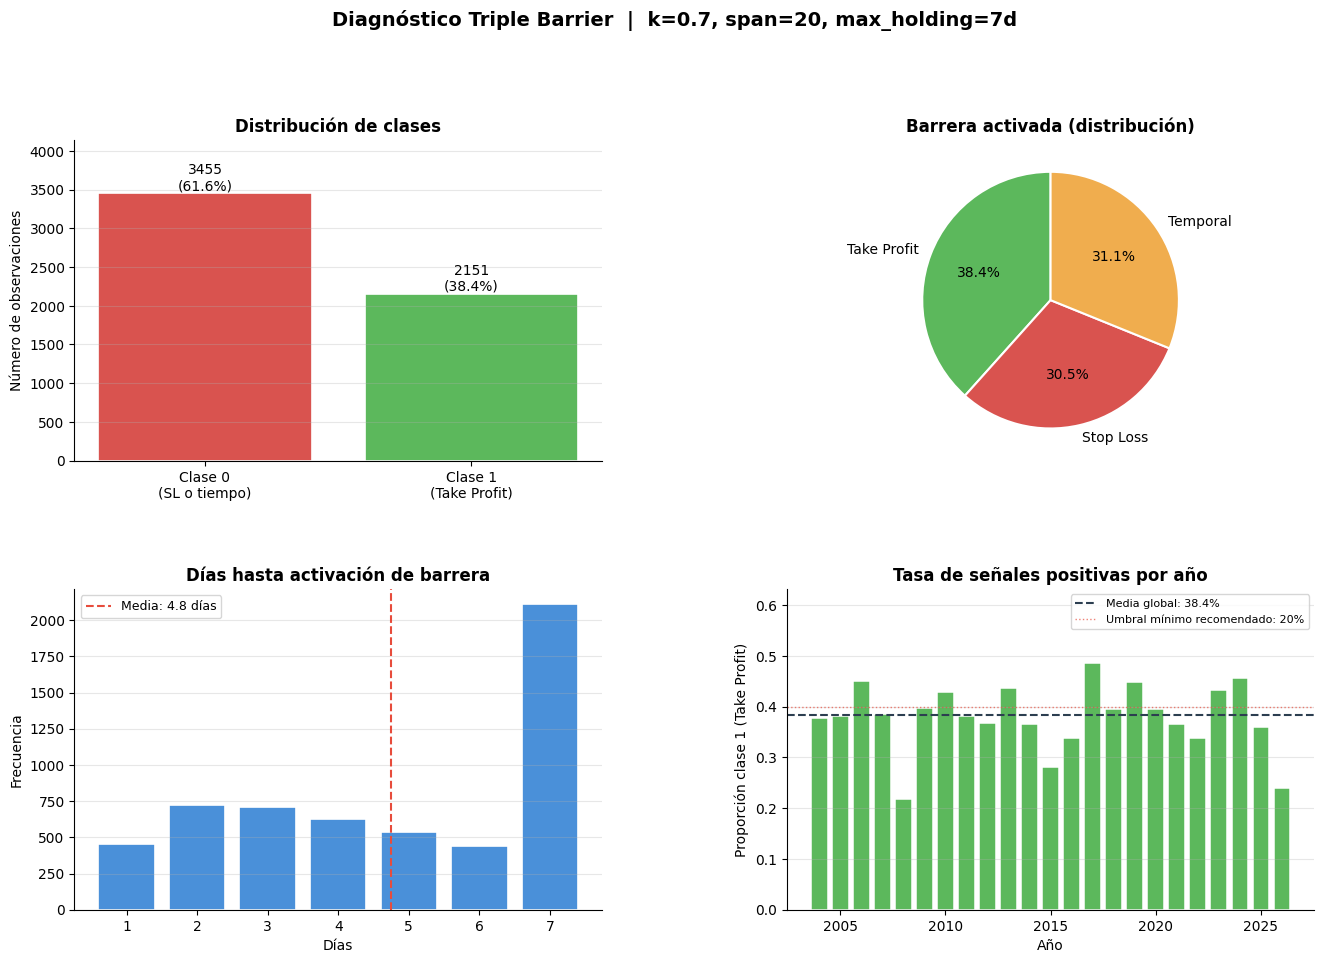

  RESUMEN DIAGNÓSTICO — TRIPLE BARRIER
  Total observaciones          :    5,606
  Clase 1 (Take Profit)        :   38.4%  ✅
  Barrera temporal activada    :   31.1%  ✅
  Barrera TP activada          :   38.4%
  Barrera SL activada          :   30.5%
  Media días hasta barrera     :     4.8d ✅
  Parámetros usados: k=0.7, span=20, max_holding=7


In [77]:
analyze_triple_barrier(dataset)

## 9.2 Visualización de barreras sobre el precio

Representamos las barreras dinámicas sobre un tramo del precio para
verificar visualmente que son coherentes con la volatilidad del mercado.
Se muestra un ventana de 120 días del periodo más reciente del train-val.

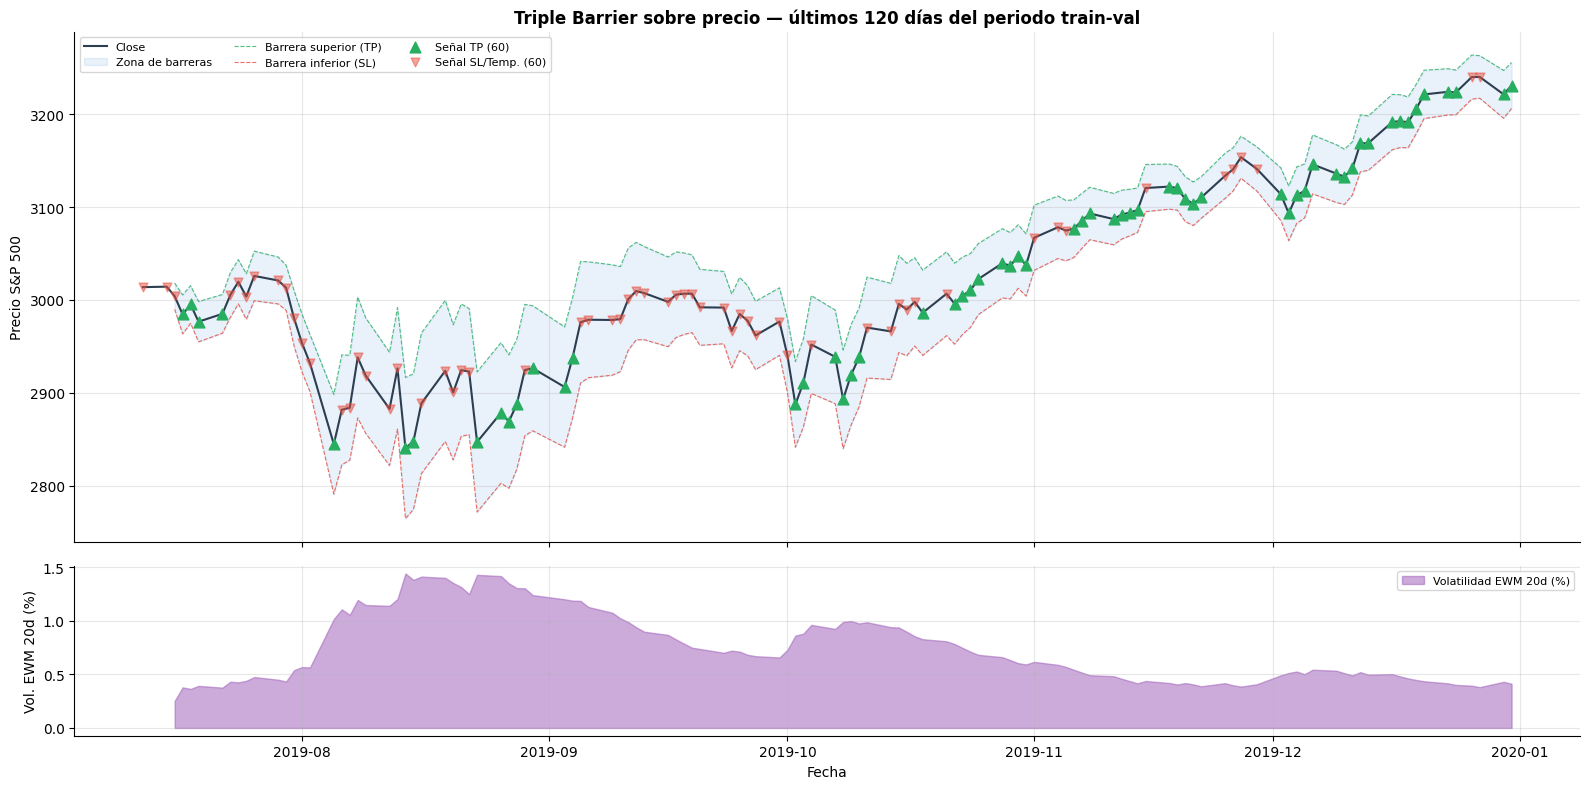

In [78]:
def plot_barriers_on_price(
    df: pd.DataFrame,
    n_days: int = 120,
    subset_end: str = TRAIN_END
) -> None:
    """
    Representa las barreras superior e inferior de la Triple Barrier
    sobre el gráfico de precios para una ventana temporal dada.

    Recalcula las barreras directamente a partir de Close y vol_ewm_20
    para garantizar la alineación correcta con el precio, independientemente
    de cualquier shift aplicado al dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con columnas 'Close', 'vol_ewm_20' y 'target_tb'.
    n_days : int, optional
        Número de días a mostrar (default: 120).
    subset_end : str, optional
        Fecha de fin de la ventana en formato 'YYYY-MM-DD' (default: TRAIN_END).

    Returns
    -------
    None
    """
    # Seleccionar ventana temporal del periodo train-val
    subset = df.loc[:subset_end].tail(n_days).copy()

    # Recalcular barreras sobre el precio real (sin shift) para la visualización
    # Usamos Close directamente del dataset original de precios
    close_vals = subset['Close'].values

    # vol_ewm_20 puede estar shifteada; recalculamos sobre los log-retornos del subset
    log_ret = np.log(subset['Close'] / subset['Close'].shift(1))
    vol_viz = log_ret.ewm(span=TB_VOL_SPAN, adjust=False).std()

    h_sqrt        = np.sqrt(TB_MAX_HOLDING)
    barrier_width = TB_K * vol_viz * h_sqrt
    tb_upper_viz  = subset['Close'] * (1 + barrier_width)
    tb_lower_viz  = subset['Close'] * (1 - barrier_width)

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1]})

    # --- Panel superior: precio + barreras ---
    ax = axes[0]
    ax.plot(subset.index, subset['Close'], color='#2c3e50', linewidth=1.5,
            label='Close', zorder=3)
    ax.fill_between(subset.index, tb_upper_viz, tb_lower_viz,
                     alpha=0.12, color='#4a90d9', label='Zona de barreras')
    ax.plot(subset.index, tb_upper_viz, color='#27ae60', linewidth=0.8,
            linestyle='--', alpha=0.8, label='Barrera superior (TP)')
    ax.plot(subset.index, tb_lower_viz, color='#e74c3c', linewidth=0.8,
            linestyle='--', alpha=0.8, label='Barrera inferior (SL)')

    # Marcar señales positivas (TP alcanzado)
    tp_signals = subset[subset['target_tb'] == 1]
    ax.scatter(tp_signals.index, tp_signals['Close'], marker='^',
               color='#27ae60', s=60, zorder=5,
               label=f'Señal TP ({len(tp_signals)})')

    # Marcar señales negativas (SL o temporal)
    sl_signals = subset[subset['target_tb'] == 0]
    ax.scatter(sl_signals.index, sl_signals['Close'], marker='v',
               color='#e74c3c', s=40, zorder=5, alpha=0.5,
               label=f'Señal SL/Temp. ({len(sl_signals)})')

    ax.set_title(
        f'Triple Barrier sobre precio — últimos {n_days} días del periodo train-val',
        fontweight='bold'
    )
    ax.set_ylabel('Precio S&P 500')
    ax.legend(fontsize=8, ncol=3, loc='upper left')
    ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # --- Panel inferior: volatilidad EWM recalculada ---
    ax2 = axes[1]
    ax2.fill_between(subset.index, vol_viz * 100, alpha=0.5,
                      color='#9b59b6', label='Volatilidad EWM 20d (%)')
    ax2.set_ylabel('Vol. EWM 20d (%)')
    ax2.set_xlabel('Fecha')
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)
    ax2.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.savefig('triple_barrier_precio.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_barriers_on_price(dataset)


---
# 10. Limpieza de variables — Correlación y VIF

## ¿Por qué hacer esta limpieza antes del modelado?

Con ~45 features, es probable que existan grupos de variables altamente
redundantes. Esta limpieza previa tiene dos objetivos:

1. **Eliminar ruido colineal** que puede desestabilizar algunos modelos
   (especialmente EBM y RuleFit).
2. **Reducir el espacio de búsqueda** de la selección de features posterior
   (que se hará por fold con SHAP dentro del walk-forward).

## Criterios de eliminación

| Criterio | Umbral | Acción |
|---|---|---|
| Correlación de Pearson/Spearman | \|corr\| > 0.95 | Eliminar una de cada par |
| VIF (Variance Inflation Factor) | VIF > 10 | Eliminar la de mayor VIF |

**Regla especial:** el VIX (`vix`) nunca se elimina, independientemente
de su VIF, porque es una feature macroeconómica de referencia que también
se usará como input del HMM en la Iteración 2.

> **Nota:** Esta limpieza es intencionalmente **conservadora**.
> La selección fina de features se realizará dentro del walk-forward
> por fold usando importancias SHAP, donde se garantiza no-leakage.

In [89]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def remove_correlated_features(
    df: pd.DataFrame,
    feature_cols: list,
    threshold: float = CORR_THRESHOLD,
    protected: list = None
) -> tuple:
    """
    Elimina features con correlación absoluta de Pearson superior al umbral.

    Para cada par de features con |corr| > threshold, se elimina la que
    tenga menor varianza (considerada menos informativa). Las features
    protegidas nunca se eliminan.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con las features a analizar.
    feature_cols : list of str
        Columnas a considerar en el análisis de correlación.
    threshold : float, optional
        Umbral de correlación absoluta (default: CORR_THRESHOLD = 0.95).
    protected : list of str, optional
        Features que nunca se eliminan (ej. ['vix']).

    Returns
    -------
    tuple (list, dict)
        - Lista de features tras la limpieza.
        - Diccionario {feature_eliminada: feature_con_la_que_correlacionaba}.
    """
    if protected is None:
        protected = []

    corr_matrix   = df[feature_cols].corr(method='pearson').abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    eliminated = {}  # {feature_eliminada: feature_causante}

    for col in upper_triangle.columns:
        if col in eliminated:
            continue
        # Features que tienen alta correlación con 'col'
        high_corr = upper_triangle[col][upper_triangle[col] > threshold].index.tolist()
        for correlated_col in high_corr:
            if correlated_col in eliminated or correlated_col in protected:
                continue
            if col in protected:
                # Si 'col' está protegida, eliminar correlated_col
                eliminated[correlated_col] = col
            else:
                # Eliminar la que tiene menor varianza
                var_col         = df[col].var()
                var_corr        = df[correlated_col].var()
                to_remove       = col if var_col < var_corr else correlated_col
                eliminated[to_remove] = correlated_col if to_remove == col else col

    remaining = [c for c in feature_cols if c not in eliminated]
    return remaining, eliminated

def remove_high_vif_features(
    df: pd.DataFrame,
    feature_cols: list,
    threshold: float = VIF_THRESHOLD,
    protected: list = None
) -> tuple:
    """
    Elimina iterativamente las features con VIF superior al umbral.

    El VIF (Variance Inflation Factor) mide cuánto se infla la varianza
    de un coeficiente de regresión por la multicolinealidad. Un VIF > 10
    indica multicolinealidad severa. El proceso es iterativo: se elimina
    la feature de mayor VIF y se recalcula hasta que todos los VIF
    estén bajo el umbral.

    El VIF se calcula únicamente sobre el periodo train-val para no
    contaminar el conjunto OOS.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con las features a analizar.
    feature_cols : list of str
        Columnas a considerar.
    threshold : float, optional
        Umbral de VIF (default: VIF_THRESHOLD = 10.0).
    protected : list of str, optional
        Features que nunca se eliminan (ej. ['vix']).

    Returns
    -------
    tuple (list, dict)
        - Lista de features tras la limpieza.
        - Diccionario {feature_eliminada: vif_en_el_momento_de_eliminación}.
    """
    if protected is None:
        protected = []

    # Filtrar solo columnas numéricas presentes en el DataFrame
    cols = [c for c in feature_cols if c in df.columns]
    eliminated = {}

    # Usar solo el periodo train para calcular VIF (no contaminar con OOS)
    X_full = (
        df.loc[:TRAIN_END, cols]
        .select_dtypes(include=[np.number])   # Solo numéricas
        .dropna()
    )
    # Actualizar cols para incluir solo las que quedaron tras filtrar
    cols = [c for c in cols if c in X_full.columns]

    # Necesitamos al menos 2 features para calcular VIF
    if len(cols) < 2:
        print('  ⚠️  Menos de 2 features disponibles; se omite el cálculo de VIF.')
        return cols, eliminated

    # Eliminar columnas con varianza cero (constantes) — causarían división por cero
    zero_var = X_full[cols].var()
    const_cols = zero_var[zero_var == 0].index.tolist()
    if const_cols:
        print(f'  ⚠️  Columnas constantes eliminadas antes del VIF: {const_cols}')
        for c in const_cols:
            if c not in protected:
                eliminated[c] = 'constante (var=0)'
                cols.remove(c)

    while len(cols) >= 2:
        X = X_full[cols].values  # Array numpy (n_samples, n_features)

        # Calcular VIF para cada feature
        try:
            vif_values = {
                col: variance_inflation_factor(X, i)
                for i, col in enumerate(cols)
            }
        except Exception as e:
            print(f'  ⚠️  Error calculando VIF: {e}. Se detiene la limpieza VIF.')
            break

        vif_series = pd.Series(vif_values).sort_values(ascending=False)
        max_vif    = vif_series.iloc[0]
        max_feat   = vif_series.index[0]

        if max_vif <= threshold:
            break  # Todos los VIF bajo el umbral → terminar

        # Si la feature de mayor VIF está protegida, buscar la siguiente candidata
        if max_feat in protected:
            candidates = vif_series[
                (vif_series > threshold) & (~vif_series.index.isin(protected))
            ]
            if candidates.empty:
                break  # Solo quedan protegidas con VIF alto → no podemos eliminar más
            max_feat = candidates.index[0]
            max_vif  = candidates.iloc[0]

        eliminated[max_feat] = round(float(max_vif), 2)
        cols.remove(max_feat)
        print(f'  Eliminada: {max_feat:<30}  VIF = {max_vif:.1f}')

    return cols, eliminated


print('✅ Función remove_high_vif_features (v2) definida')


✅ Función remove_high_vif_features (v2) definida


## 10.1 Definir features a analizar

In [90]:
# Columnas que NO son features del modelo
NON_FEATURE_COLS = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'target_return_1d',                          # Target de referencia
    'target_tb',                                 # Target principal
    'tb_barrier_hit', 'tb_days_to_barrier',      # Metadata del target
    'tb_upper', 'tb_lower'                       # Niveles de barrera
]

# Features disponibles para el modelo
feature_cols = [c for c in dataset.columns if c not in NON_FEATURE_COLS]

# Features protegidas — nunca se eliminan
PROTECTED_FEATURES = ['vix']  # Usado también como input del HMM (Iteración 2)

print(f'Features antes de limpieza : {len(feature_cols)}')
print(f'Features protegidas        : {PROTECTED_FEATURES}')
print(f'\nLista completa:')
for i, f in enumerate(feature_cols, 1):
    print(f'  {i:>2}. {f}')

Features antes de limpieza : 40
Features protegidas        : ['vix']

Lista completa:
   1. sma_10
   2. sma_50
   3. ema_10
   4. momentum_5
   5. momentum_20
   6. rsi
   7. vol_ewm_20
   8. volatility_20
   9. atr_14
  10. zscore_20
  11. trend_strength
  12. return_1d
  13. return_5d
  14. return_20d
  15. vol_regime
  16. drawdown
  17. recession
  18. yield_curve
  19. corp_oas
  20. hy_oas
  21. eu_hy_oas
  22. sentiment
  23. empleo
  24. real_gdp
  25. oil
  26. inflacion
  27. leading
  28. vix
  29. vixoil
  30. weekjobclaims
  31. retail_sales_percent
  32. retail_sales
  33. us_asset_balance
  34. 1y_yield
  35. sector_XLE
  36. sector_XLF
  37. sector_XLI
  38. sector_XLK
  39. sector_XLV
  40. sector_XLY


## 10.2 Limpieza por correlación

In [91]:
cols_after_corr, eliminated_corr = remove_correlated_features(
    df=dataset.loc[:TRAIN_END],  # Solo calcular sobre train-val
    feature_cols=feature_cols,
    threshold=CORR_THRESHOLD,
    protected=PROTECTED_FEATURES
)

print(f'Features eliminadas por correlación (|r| > {CORR_THRESHOLD}): '
      f'{len(eliminated_corr)}')
print(f'Features restantes: {len(cols_after_corr)}')

if eliminated_corr:
    print('\nDetalle de eliminaciones:')
    for feat, corr_with in eliminated_corr.items():
        print(f'  ✗ {feat:<30} (alta correlación con: {corr_with})')

Features eliminadas por correlación (|r| > 0.95): 6
Features restantes: 34

Detalle de eliminaciones:
  ✗ sma_50                         (alta correlación con: sma_10)
  ✗ ema_10                         (alta correlación con: sma_10)
  ✗ momentum_5                     (alta correlación con: return_5d)
  ✗ momentum_20                    (alta correlación con: return_20d)
  ✗ sma_10                         (alta correlación con: real_gdp)
  ✗ real_gdp                       (alta correlación con: retail_sales)


## 10.3 Visualización de la matriz de correlación

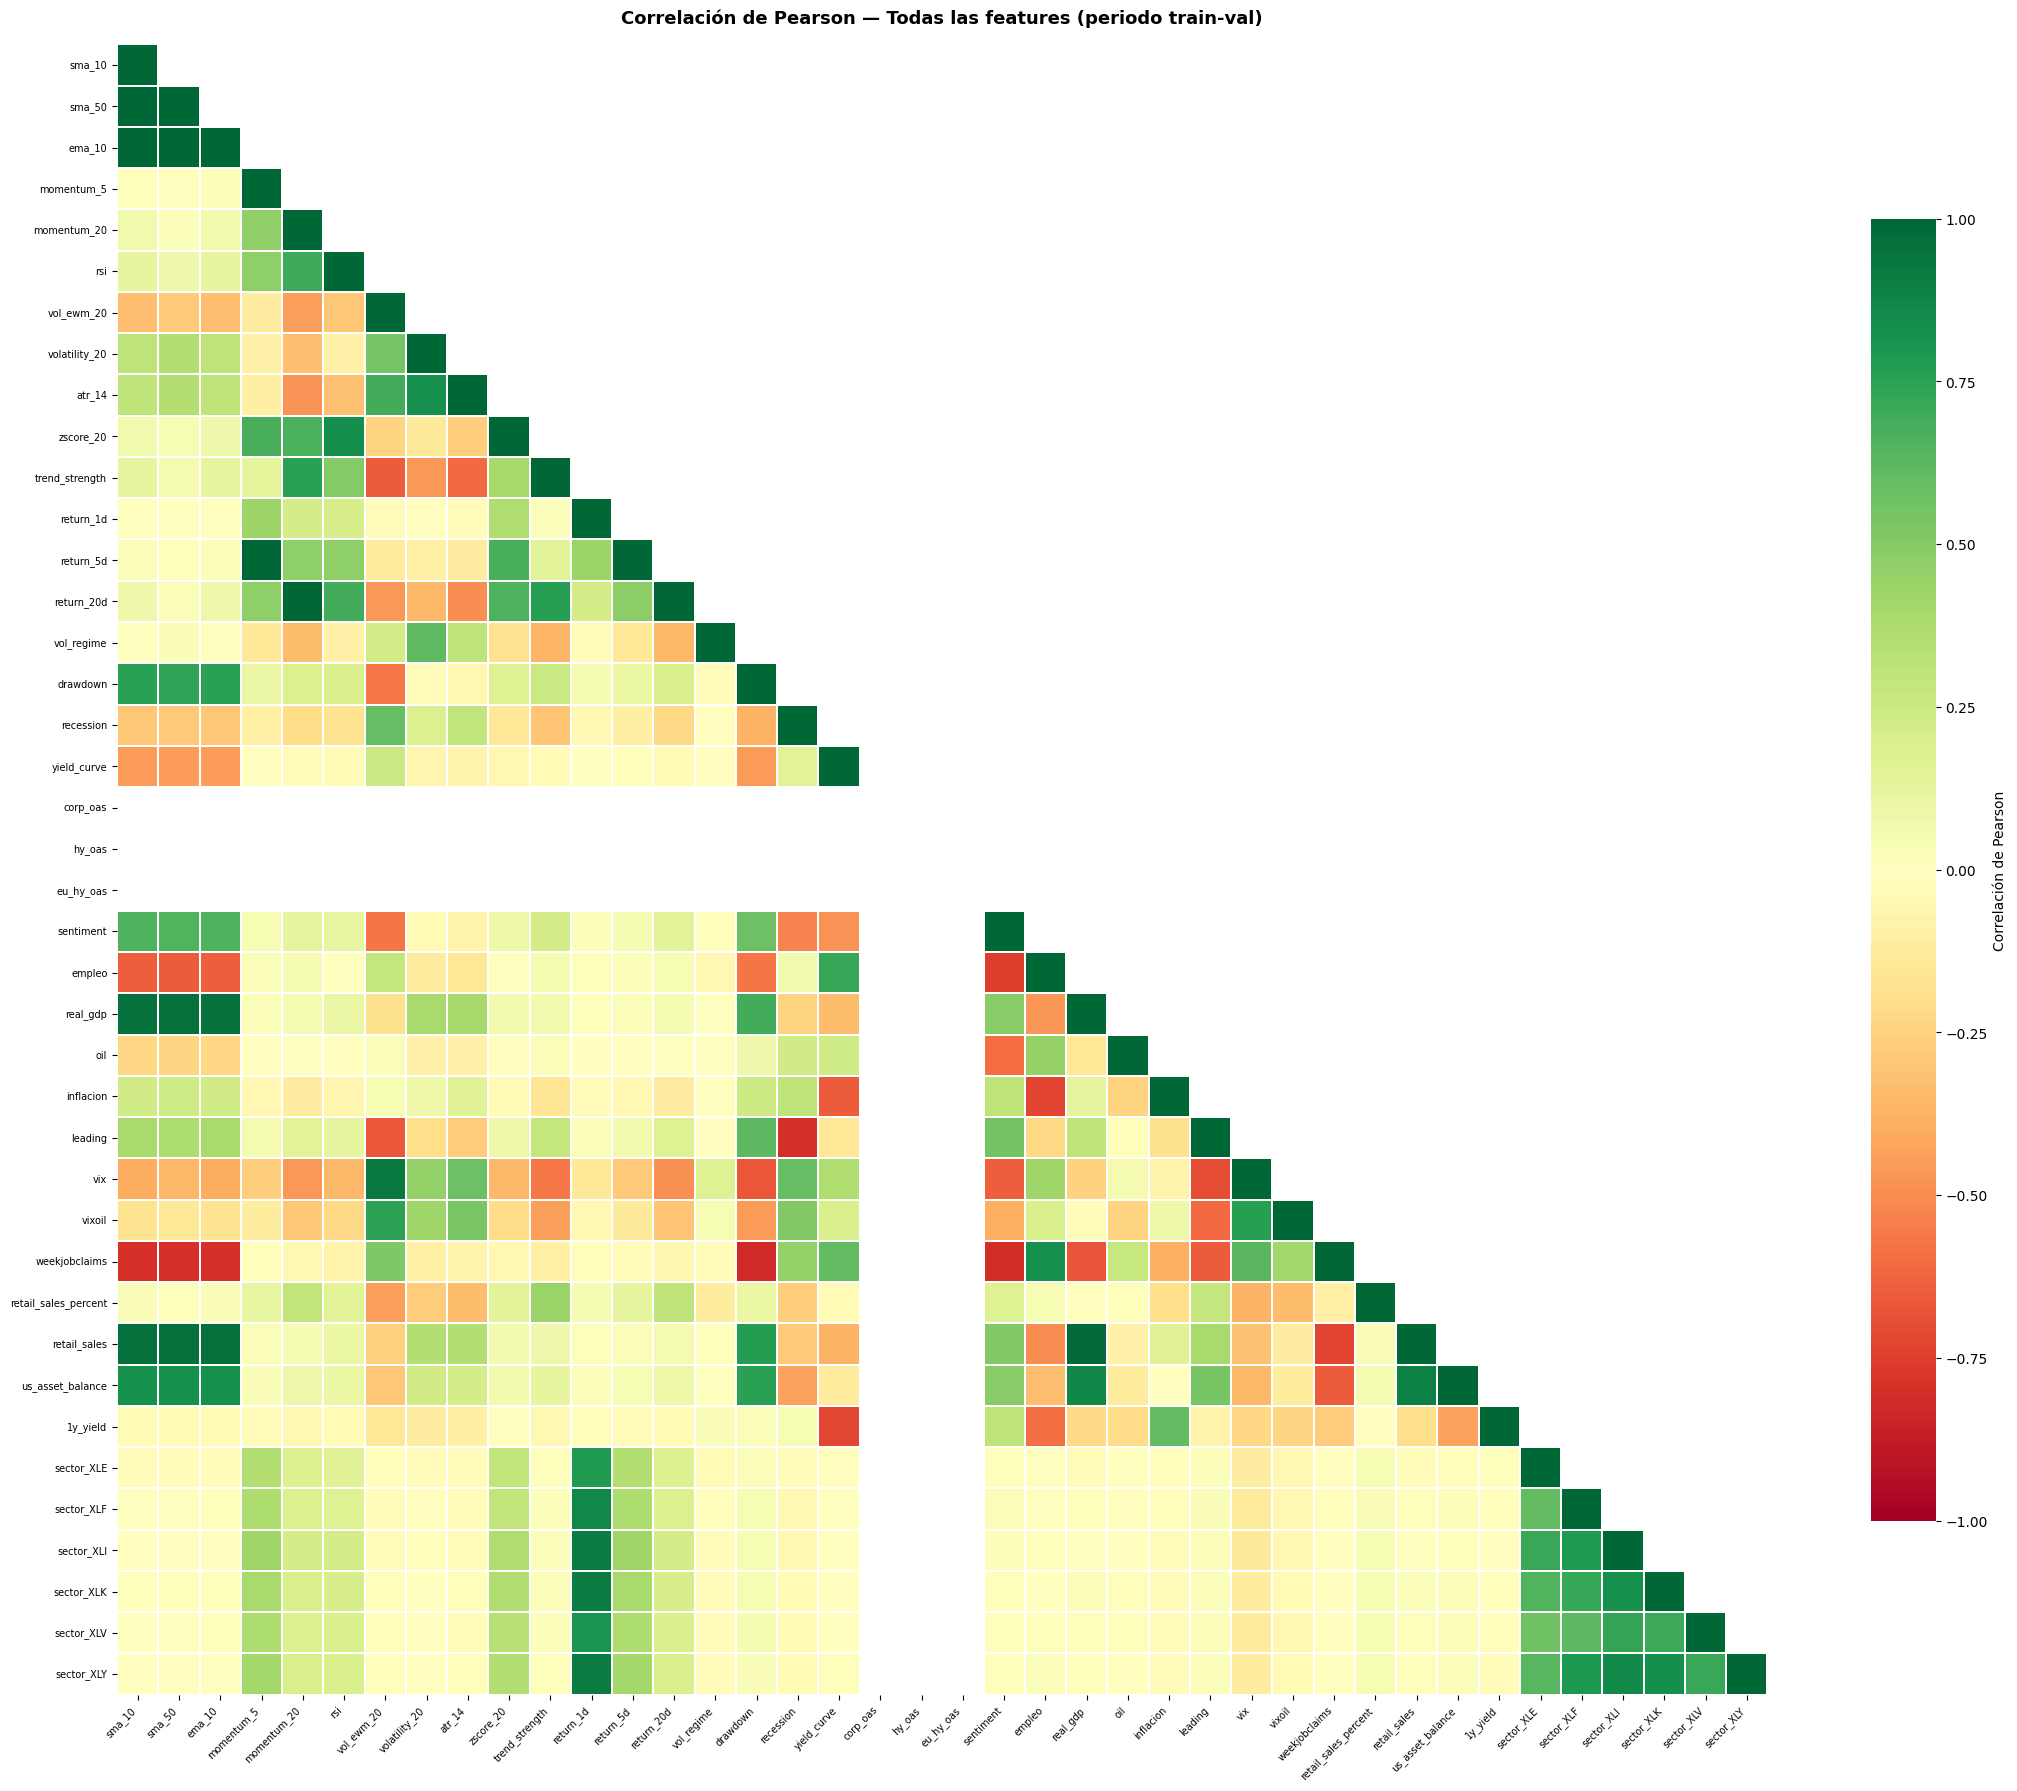

In [92]:
import seaborn as sns
def plot_correlation_matrix(
    df: pd.DataFrame,
    feature_cols: list,
    title: str = 'Matriz de correlación de Pearson'
) -> None:
    """
    Visualiza la matriz de correlación como heatmap (triángulo inferior).

    Parameters
    ----------
    df : pd.DataFrame
        Dataset con las features.
    feature_cols : list of str
        Columnas a incluir en el heatmap.
    title : str, optional
        Título del gráfico.

    Returns
    -------
    None
    """
    corr = df[feature_cols].corr(method='pearson')

    n = len(feature_cols)
    fig, ax = plt.subplots(figsize=(max(12, n * 0.55), max(10, n * 0.55)))

    # Enmascarar el TRIÁNGULO SUPERIOR (mostrar solo inferior + diagonal)
    # np.triu devuelve 1 en la parte superior → mask=True oculta esas celdas
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.heatmap(
        corr,
        mask=mask,                          # ocultar triángulo superior
        annot=(n <= 20),                    # anotar solo si hay pocas features
        fmt='.2f',
        cmap='RdYlGn',
        vmin=-1, vmax=1, center=0,
        square=True,
        linewidths=0.3,
        linecolor='white',
        cbar_kws={'shrink': 0.6, 'label': 'Correlación de Pearson'},
        ax=ax
    )
    ax.set_title(title, fontweight='bold', pad=15, fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig('correlacion_features.png', dpi=150, bbox_inches='tight')
    plt.show()


# Heatmap sobre el periodo train-val
plot_correlation_matrix(
    df=dataset.loc[:TRAIN_END],
    feature_cols=feature_cols,
    title='Correlación de Pearson — Todas las features (periodo train-val)'
)


## 10.4 Limpieza por VIF

In [93]:
cols_after_vif, eliminated_vif = remove_high_vif_features(
    df=dataset,
    feature_cols=cols_after_corr,
    threshold=VIF_THRESHOLD,
    protected=PROTECTED_FEATURES
)

print(f'Features eliminadas por VIF > {VIF_THRESHOLD}: {len(eliminated_vif)}')
print(f'Features restantes tras limpieza VIF: {len(cols_after_vif)}')

if eliminated_vif:
    print('\nDetalle de eliminaciones:')
    for feat, vif_val in sorted(eliminated_vif.items(), key=lambda x: -x[1]):
        print(f'  ✗ {feat:<30} VIF = {vif_val:.1f}')

  Eliminada: return_1d                       VIF = 57.4
  Eliminada: empleo                          VIF = 33.0
  Eliminada: retail_sales                    VIF = 25.6
  Eliminada: vol_ewm_20                      VIF = 17.7
  Eliminada: weekjobclaims                   VIF = 15.8
  Eliminada: us_asset_balance                VIF = 12.4
Features eliminadas por VIF > 10.0: 6
Features restantes tras limpieza VIF: 28

Detalle de eliminaciones:
  ✗ return_1d                      VIF = 57.4
  ✗ empleo                         VIF = 33.0
  ✗ retail_sales                   VIF = 25.6
  ✗ vol_ewm_20                     VIF = 17.7
  ✗ weekjobclaims                  VIF = 15.8
  ✗ us_asset_balance               VIF = 12.4


## 10.5 Resumen final de la limpieza

In [94]:
def summarize_cleaning(
    original: list,
    after_corr: list,
    after_vif: list,
    eliminated_corr: dict,
    eliminated_vif: dict
) -> pd.DataFrame:
    """
    Genera un resumen tabular del proceso de limpieza de variables.

    Parameters
    ----------
    original : list
        Features antes de cualquier limpieza.
    after_corr : list
        Features tras la limpieza por correlación.
    after_vif : list
        Features tras la limpieza por VIF.
    eliminated_corr : dict
        Eliminadas por correlación {feature: causa}.
    eliminated_vif : dict
        Eliminadas por VIF {feature: vif_value}.

    Returns
    -------
    pd.DataFrame
        Tabla con cada feature, su estado y la razón de eliminación si aplica.
    """
    rows = []
    for feat in original:
        if feat in eliminated_corr:
            status = 'Eliminada'
            reason = f'Correlación con {eliminated_corr[feat]}'
        elif feat in eliminated_vif:
            status = 'Eliminada'
            reason = f'VIF = {eliminated_vif[feat]:.1f}'
        else:
            status = 'Mantenida'
            reason = '—'
        rows.append({'Feature': feat, 'Estado': status, 'Razón': reason})

    summary_df = pd.DataFrame(rows)
    return summary_df


summary = summarize_cleaning(
    original=feature_cols,
    after_corr=cols_after_corr,
    after_vif=cols_after_vif,
    eliminated_corr=eliminated_corr,
    eliminated_vif=eliminated_vif
)

print('RESUMEN FINAL DE LIMPIEZA DE VARIABLES')
print('=' * 60)
print(f'  Features originales          : {len(feature_cols)}')
print(f'  Eliminadas por correlación   : {len(eliminated_corr)}')
print(f'  Eliminadas por VIF           : {len(eliminated_vif)}')
print(f'  Features para modelado       : {len(cols_after_vif)}')
print('=' * 60)
print()
print(summary.to_string(index=False))

# Guardar el log de limpieza como referencia
summary.to_csv('feature_cleaning_log.csv', index=False)
print('\n✅ Log guardado en feature_cleaning_log.csv')

RESUMEN FINAL DE LIMPIEZA DE VARIABLES
  Features originales          : 40
  Eliminadas por correlación   : 6
  Eliminadas por VIF           : 6
  Features para modelado       : 28

             Feature    Estado                        Razón
              sma_10 Eliminada     Correlación con real_gdp
              sma_50 Eliminada       Correlación con sma_10
              ema_10 Eliminada       Correlación con sma_10
          momentum_5 Eliminada    Correlación con return_5d
         momentum_20 Eliminada   Correlación con return_20d
                 rsi Mantenida                            —
          vol_ewm_20 Eliminada                   VIF = 17.7
       volatility_20 Mantenida                            —
              atr_14 Mantenida                            —
           zscore_20 Mantenida                            —
      trend_strength Mantenida                            —
           return_1d Eliminada                   VIF = 57.4
           return_5d Mantenida        

## 10.6 Dataset final para modelado

In [95]:
# Columnas del dataset final (features limpias + target)
FINAL_FEATURE_COLS = cols_after_vif
TARGET_COL         = 'target_tb'

# Separar en train-val y OOS (el OOS no se toca hasta la evaluación final)
dataset_train = dataset.loc[:TRAIN_END, FINAL_FEATURE_COLS + [TARGET_COL]].copy()
dataset_oos   = dataset.loc[OOS_START:, FINAL_FEATURE_COLS + [TARGET_COL]].copy()

print('✅ Dataset final preparado')
print(f'   Features para modelado : {len(FINAL_FEATURE_COLS)}')
print(f'   Train-val ({START_DATE[:4]}–{TRAIN_END[:4]}): {dataset_train.shape}')
print(f'   OOS  ({OOS_START[:4]}–{OOS_END[:4]}) [🔒]: {dataset_oos.shape}')
print(f'   Distribución target train: {dataset_train[TARGET_COL].value_counts().to_dict()}')

✅ Dataset final preparado
   Features para modelado : 28
   Train-val (2004–2019): (4027, 29)
   OOS  (2020–2024) [🔒]: (1579, 29)
   Distribución target train: {0.0: 2483, 1.0: 1544}


---
# 11. Guardado del dataset

Guardamos el dataset completo en Parquet y descargamos los archivos.
El formato Parquet es más eficiente que CSV para datos numéricos:
mantiene los tipos de datos, ocupa menos espacio y carga más rápido.

---
# 11. Guardado persistente en Google Drive

## Estrategia de persistencia entre notebooks

En Google Colab cada sesión empieza desde cero: las variables y archivos
del entorno se pierden al cerrar el navegador o al que la sesión expire.
Para evitar tener que re-ejecutar el Bloque 0 cada vez que trabajemos en
la Iteración 1 o 2, guardamos todos los artefactos en **Google Drive**,
en la carpeta `MyDrive/tfm/data/`.

```
MyDrive/
└── tfm/
    └── data/
        ├── dataset_sp500_bloque0.parquet   ← Dataset completo (features + target)
        ├── dataset_train_val.parquet       ← Train-val con features limpias
        ├── feature_list_bloque0.csv        ← Lista de features para modelado
        └── feature_cleaning_log.csv        ← Log de features eliminadas
```

Los notebooks de Iteración 1 e Iteración 2 **montan Drive y leen directamente**
desde esa carpeta, sin necesidad de subir archivos manualmente.

> **Cuándo re-ejecutar este bloque:** solo si cambias parámetros del Bloque 0
> (k de la Triple Barrier, features, periodo de datos, etc.). En ese caso
> los archivos en Drive se sobreescriben automáticamente con los nuevos resultados.

In [96]:
import os
from google.colab import drive

# ── Montar Google Drive ───────────────────────────────────────────────────────
# Se pedirá autorización la primera vez. Acepta desde tu cuenta de Google.
drive.mount('/content/drive', force_remount=False)

# ── Definir ruta del proyecto en Drive ───────────────────────────────────────
DRIVE_DATA_DIR = '/content/drive/MyDrive/tfm/data'
os.makedirs(DRIVE_DATA_DIR, exist_ok=True)

print(f'✅ Google Drive montado')
print(f'   Carpeta de datos: {DRIVE_DATA_DIR}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado
   Carpeta de datos: /content/drive/MyDrive/tfm/data


## 11.1 Guardar artefactos del Bloque 0

In [97]:
# Columnas del dataset final (features limpias + target)
# Estas variables deben estar definidas desde la sección 10
FINAL_FEATURE_COLS = cols_after_vif
TARGET_COL         = 'target_tb'

# Separar en train-val y OOS
dataset_train = dataset.loc[:TRAIN_END, FINAL_FEATURE_COLS + [TARGET_COL]].copy()
dataset_oos   = dataset.loc[OOS_START:, FINAL_FEATURE_COLS + [TARGET_COL]].copy()

# ── Definir artefactos a guardar ─────────────────────────────────────────────
artifacts = {
    'dataset_sp500_bloque0.parquet' : dataset,           # Dataset completo
    'dataset_train_val.parquet'     : dataset_train,     # Solo train-val
    'feature_cleaning_log.csv'      : summary,           # Log de limpieza
}
feature_list_path = os.path.join(DRIVE_DATA_DIR, 'feature_list_bloque0.csv')

# ── Guardar en Drive ──────────────────────────────────────────────────────────
for filename, data in artifacts.items():
    path = os.path.join(DRIVE_DATA_DIR, filename)
    if filename.endswith('.parquet'):
        data.to_parquet(path)
    else:
        data.to_csv(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f'  ✅ {filename:<45} ({size_kb:.0f} KB)')

# Guardar lista de features
pd.Series(FINAL_FEATURE_COLS, name='feature').to_csv(feature_list_path, index=False)
size_kb = os.path.getsize(feature_list_path) / 1024
print(f'  ✅ feature_list_bloque0.csv                       ({size_kb:.0f} KB)')

print()
print(f'✅ Todos los artefactos guardados en:')
print(f'   {DRIVE_DATA_DIR}')
print()
print('📋 Resumen del dataset guardado:')
print(f'   Dataset completo  : {dataset.shape[0]:,} filas × {dataset.shape[1]} columnas')
print(f'   Train-val         : {dataset_train.shape[0]:,} filas  ({dataset_train.index[0].date()} → {dataset_train.index[-1].date()})')
print(f'   OOS [🔒]          : {dataset_oos.shape[0]:,} filas  ({dataset_oos.index[0].date()} → {dataset_oos.index[-1].date()})')
print(f'   Features finales  : {len(FINAL_FEATURE_COLS)}')
print()
print('➡️  Para usar en la Iteración 1: monta Drive y lee desde la misma carpeta.')
print(f'   DRIVE_DATA_DIR = \'{DRIVE_DATA_DIR}\'')


  ✅ dataset_sp500_bloque0.parquet                 (1671 KB)
  ✅ dataset_train_val.parquet                     (662 KB)
  ✅ feature_cleaning_log.csv                      (1 KB)
  ✅ feature_list_bloque0.csv                       (0 KB)

✅ Todos los artefactos guardados en:
   /content/drive/MyDrive/tfm/data

📋 Resumen del dataset guardado:
   Dataset completo  : 5,606 filas × 51 columnas
   Train-val         : 4,027 filas  (2004-01-02 → 2019-12-31)
   OOS [🔒]          : 1,579 filas  (2020-01-02 → 2026-04-15)
   Features finales  : 28

➡️  Para usar en la Iteración 1: monta Drive y lee desde la misma carpeta.
   DRIVE_DATA_DIR = '/content/drive/MyDrive/tfm/data'


## 11.2 Verificación de integridad

In [98]:
def verify_drive_artifacts(drive_dir: str) -> bool:
    """
    Verifica que todos los artefactos del Bloque 0 se guardaron correctamente
    en Google Drive y que son legibles y coherentes entre sí.

    Parameters
    ----------
    drive_dir : str
        Ruta a la carpeta de datos en Google Drive.

    Returns
    -------
    bool
        True si todos los artefactos son válidos, False en caso contrario.
    """
    required = [
        'dataset_sp500_bloque0.parquet',
        'dataset_train_val.parquet',
        'feature_list_bloque0.csv',
        'feature_cleaning_log.csv',
    ]

    all_ok = True
    print('Verificando artefactos en Drive...')

    for fname in required:
        path = os.path.join(drive_dir, fname)
        if not os.path.exists(path):
            print(f'  ❌ No encontrado : {fname}')
            all_ok = False
            continue

        # Leer y verificar
        try:
            if fname.endswith('.parquet'):
                df_check = pd.read_parquet(path)
                size_kb  = os.path.getsize(path) / 1024
                print(f'  ✅ {fname:<45} {df_check.shape}  ({size_kb:.0f} KB)')
            else:
                df_check = pd.read_csv(path)
                print(f'  ✅ {fname:<45} {df_check.shape}')
        except Exception as e:
            print(f'  ❌ Error leyendo {fname}: {e}')
            all_ok = False

    # Verificar coherencia: features del CSV presentes en el parquet
    try:
        feats    = pd.read_csv(os.path.join(drive_dir, 'feature_list_bloque0.csv'))['feature'].tolist()
        df_full  = pd.read_parquet(os.path.join(drive_dir, 'dataset_sp500_bloque0.parquet'))
        missing  = [f for f in feats if f not in df_full.columns]
        if missing:
            print(f'  ⚠️  Features en CSV no presentes en parquet: {missing}')
            all_ok = False
        else:
            print(f'  ✅ Coherencia features CSV ↔ parquet         ({len(feats)} features OK)')
    except Exception as e:
        print(f'  ⚠️  No se pudo verificar coherencia: {e}')

    print()
    if all_ok:
        print('✅ Todos los artefactos verificados correctamente.')
        print('   La Iteración 1 puede montare Drive y leer directamente.')
    else:
        print('❌ Algunos artefactos tienen problemas. Re-ejecuta las celdas de guardado.')

    return all_ok


verify_drive_artifacts(DRIVE_DATA_DIR)


Verificando artefactos en Drive...
  ✅ dataset_sp500_bloque0.parquet                 (5606, 51)  (1671 KB)
  ✅ dataset_train_val.parquet                     (4027, 29)  (662 KB)
  ✅ feature_list_bloque0.csv                      (28, 1)
  ✅ feature_cleaning_log.csv                      (40, 3)
  ✅ Coherencia features CSV ↔ parquet         (28 features OK)

✅ Todos los artefactos verificados correctamente.
   La Iteración 1 puede montare Drive y leer directamente.


True